# Demographics exploration

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
tracts = gpd.read_file("data/philly_tracts.gpkg")
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,index_right,MAPNAME,geometry
0,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,62,Tioga,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
1,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,58,Southwest Germantown,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
2,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,61,Nicetown,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
3,42,101,020500,42101020500,1400000US42101020500,205,Census Tract 205,G5020,S,1429513,0,+40.0158738,-075.1643607,89,Logan,"POLYGON ((2689452.729 259213.458, 2689576.162 ..."
4,42,101,020600,42101020600,1400000US42101020600,206,Census Tract 206,G5020,S,1295909,56782,+40.0197999,-075.1827740,63,Allegheny West,"POLYGON ((2684720.175 260695.467, 2684866.848 ..."


In [8]:
tracts.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [10]:
tracts_sub = tracts[['TRACTCE', 'GEOID', 'NAME', 'geometry']]

In [17]:
neigh_reviews_joined = gpd.read_file("modified_data/neigh_reviews_joined.gpkg")
neigh_reviews_joined.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,index_right,LISTNAME,gentrified,geometry
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",92.0,Chinatown,0.0,POINT (-75.15556 39.95551)
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",91.0,Old City,0.0,POINT (-75.14323 39.95395)
2,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': ""u'quiet'"", 'GoodForMeal': ""{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",103.0,Hawthorne,0.0,POINT (-75.16257 39.94322)
3,QdN72BWoyFypdGJhhI5r7g,Bar One,767 S 9th St,Philadelphia,PA,19147,39.939825,-75.157447,4.0,65,0,"{'Smoking': ""u'no'"", 'NoiseLevel': ""u'average'...","Cocktail Bars, Bars, Italian, Nightlife, Resta...","{'Monday': '16:0-0:0', 'Tuesday': '16:0-0:0', ...",104.0,Bella Vista,0.0,POINT (-75.15745 39.93982)
4,Mjboz24M9NlBeiOJKLEd_Q,DeSandro on Main,4105 Main St,Philadelphia,PA,19127,40.022466,-75.218314,3.0,41,0,"{'RestaurantsReservations': 'False', 'Caters':...","Pizza, Restaurants, Salad, Soup","{'Tuesday': '17:0-21:30', 'Wednesday': '17:0-1...",51.0,Manayunk,0.0,POINT (-75.21831 40.02247)


In [21]:
neigh_reviews_joined = neigh_reviews_joined.drop('index_right', axis=1)
neigh_reviews_joined = neigh_reviews_joined.to_crs(tracts.crs)
neigh_reviews_joined.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [22]:
neigh_reviews_joined.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'gentrified',
       'geometry'],
      dtype='object')

In [23]:
# reviews joined with location info (neighborhood, tract)
reviews_loc = gpd.sjoin(neigh_reviews_joined, tracts_sub, how="left", predicate="intersects")
reviews_loc.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes,categories,hours,LISTNAME,gentrified,geometry,index_right,TRACTCE,GEOID,NAME
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Chinatown,0.0,POINT (2695729.449 237331.978),303.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Chinatown,0.0,POINT (2695729.449 237331.978),304.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Chinatown,0.0,POINT (2695729.449 237331.978),306.0,000200,42101000200,2
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Chinatown,0.0,POINT (2695729.449 237331.978),305.0,000200,42101000200,2
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,...,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",Old City,0.0,POINT (2699203.534 236867.171),55.0,000102,42101000102,1.02


In [40]:
len(reviews_loc['NAME'].unique())

371

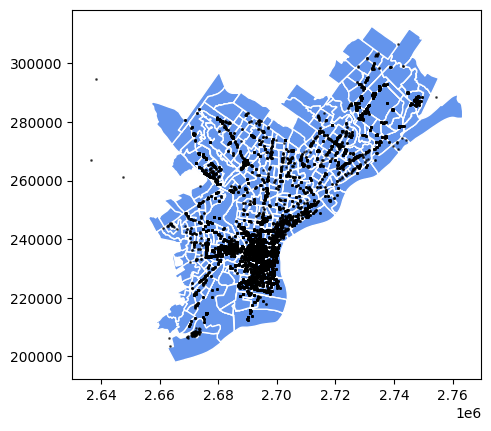

In [36]:

ax = tracts.plot(color="cornflowerblue",edgecolor="white")
reviews_loc.plot(ax=ax, markersize= 1, color="black", alpha=0.6)
plt.show()

## Merge with race and ethnicity data 

In [45]:
reviews_loc.dtypes

business_id       object
name              object
address           object
city              object
state             object
postal_code       object
latitude         float64
longitude        float64
stars            float64
review_count       int64
is_open            int64
attributes        object
categories        object
hours             object
LISTNAME          object
gentrified       float64
geometry        geometry
index_right      float64
TRACTCE           object
GEOID             object
NAME              object
dtype: object

In [47]:
race = pd.read_csv("modified_data/race_ethn_cleaned.csv")
reviews_loc['TRACTCE'] = reviews_loc['TRACTCE'].astype(str).str.zfill(6)
race['TRACTCE'] = race['TRACTCE'].astype(str).str.zfill(6)
reviews_demog = pd.merge(reviews_loc, race, how="left", on="TRACTCE")
reviews_demog.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,GEOID,NAME,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,2,2.0,1400000US42101000200,Census Tract 2; Philadelphia County; Pennsylvania,3367.0,0.084942,0.634096,0.037125,0.243837
4,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,...,42101000102,1.02,1.0,1400000US42101000102,Census Tract 1.02; Philadelphia County; Pennsy...,3511.0,0.050698,0.100826,0.059242,0.789234


In [61]:
reviews_demog = reviews_demog.rename(columns={"LISTNAME": "neighborhood"})

In [62]:
# find tracts that are predominantly POC
reviews_demog['predom_poc'] = np.where(reviews_demog['prop_white_only'] <= 0.5, 1, 0)
np.mean(reviews_demog['predom_poc'])

np.float64(0.40163798350949037)

In [63]:
pd.crosstab(reviews_demog['predom_poc'], reviews_demog['gentrified'], normalize=True)

gentrified,0.0,1.0
predom_poc,,
0,0.530074,0.067196
1,0.370991,0.031739


In [64]:
# gentrified poc
gentrified_poc = reviews_demog[(reviews_demog['predom_poc'] == 1) & (reviews_demog['gentrified'] == 1)]
gentrified_poc

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,NAME,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,predom_poc
93,VCkSUsdL5P0p16DAPxVROA,NY Bagel & Deli Shop,1120 Buttonwood St,Philadelphia,PA,19123,39.960811,-75.157388,4.0,31,...,376,370.0,1400000US42101037600,Census Tract 376; Philadelphia County; Pennsyl...,3664.0,0.176583,0.248090,0.115175,0.460153,1
94,VCkSUsdL5P0p16DAPxVROA,NY Bagel & Deli Shop,1120 Buttonwood St,Philadelphia,PA,19123,39.960811,-75.157388,4.0,31,...,376,370.0,1400000US42101037600,Census Tract 376; Philadelphia County; Pennsyl...,3664.0,0.176583,0.248090,0.115175,0.460153,1
95,VCkSUsdL5P0p16DAPxVROA,NY Bagel & Deli Shop,1120 Buttonwood St,Philadelphia,PA,19123,39.960811,-75.157388,4.0,31,...,376,370.0,1400000US42101037600,Census Tract 376; Philadelphia County; Pennsyl...,3664.0,0.176583,0.248090,0.115175,0.460153,1
96,VCkSUsdL5P0p16DAPxVROA,NY Bagel & Deli Shop,1120 Buttonwood St,Philadelphia,PA,19123,39.960811,-75.157388,4.0,31,...,376,370.0,1400000US42101037600,Census Tract 376; Philadelphia County; Pennsyl...,3664.0,0.176583,0.248090,0.115175,0.460153,1
97,VCkSUsdL5P0p16DAPxVROA,NY Bagel & Deli Shop,1120 Buttonwood St,Philadelphia,PA,19123,39.960811,-75.157388,4.0,31,...,376,370.0,1400000US42101037600,Census Tract 376; Philadelphia County; Pennsyl...,3664.0,0.176583,0.248090,0.115175,0.460153,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17889,43ZZDlfzgi8Zye2OHFyq5A,Bee Burger,7133 Germantown Ave,Philadelphia,PA,19119,40.059394,-75.190119,2.5,7,...,255,242.0,1400000US42101025500,Census Tract 255; Philadelphia County; Pennsyl...,2667.0,0.510311,0.031871,0.049119,0.408699,1
17981,mx31XU-QJIxObRGH_qvy3w,HAPP'S,1862 Frankford Ave,Philadelphia,PA,19125,39.978348,-75.130836,4.5,23,...,157,158.0,1400000US42101015700,Census Tract 157; Philadelphia County; Pennsyl...,2924.0,0.092339,0.058482,0.352941,0.496238,1
17982,mx31XU-QJIxObRGH_qvy3w,HAPP'S,1862 Frankford Ave,Philadelphia,PA,19125,39.978348,-75.130836,4.5,23,...,157,158.0,1400000US42101015700,Census Tract 157; Philadelphia County; Pennsyl...,2924.0,0.092339,0.058482,0.352941,0.496238,1
17983,mx31XU-QJIxObRGH_qvy3w,HAPP'S,1862 Frankford Ave,Philadelphia,PA,19125,39.978348,-75.130836,4.5,23,...,157,158.0,1400000US42101015700,Census Tract 157; Philadelphia County; Pennsyl...,2924.0,0.092339,0.058482,0.352941,0.496238,1


In [ ]:
poc_gentrified_neighborhoods = gentrified_poc['neighborhood'].unique()
poc_gentrified_neighborhoods

array(['Callowhill', 'Olney', 'Fairmount', 'Cobbs Creek',
       'Mount Airy, East', 'Fishtown - Lower Kensington',
       'Southwest Schuylkill'], dtype=object)

In [67]:
gentrified_white = reviews_demog[(reviews_demog['predom_poc'] == 0) & (reviews_demog['gentrified'] == 1)]


In [68]:
white_gentrified_neighborhoods = gentrified_white['neighborhood'].unique()
white_gentrified_neighborhoods

array(['Logan Square', 'Fishtown - Lower Kensington', 'Roxborough',
       'East Falls', 'Fairmount', 'Upper Roxborough', 'Roxborough Park',
       'Mount Airy, East'], dtype=object)